### Here we make plots of the training data vs validation data vs testing data

In [1]:
import torch
from Modules import pre_pro
from Modules.Neural_Net import Net
from Modules.Neural_Net import NetWrapper
from tqdm import tqdm
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import numpy as np
from torch.utils.data import DataLoader
import seaborn




### Training Data

In [2]:
'Iterate through dataloader taking rms errors.'


data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams = list(range(6, 20))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataset = pre_pro.FrameDataset(input, output)
spt_dataloader = DataLoader(dataset, shuffle=True, batch_size=1)


In [4]:
network_info = torch.load('nets/SPT/spt_250_350.pt', weights_only=True)
net = Net(torch.cos, *network_info['model config'])
net.load_state_dict(network_info['model_state_dict'])
net.to('cuda')

'hi'

'hi'

In [5]:
network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)
mse_net = Net(torch.cos, *network_info['model config'])
mse_net.load_state_dict(network_info['model_state_dict'])
mse_net.to('cuda')

'hi'

'hi'

In [6]:
'error at each point in space and time'
stats = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        stats.append(nrms)


mse_stats = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = mse_net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        mse_stats.append(nrms)


 Regulrized NRMS: 1.717678189277649, MSE NRMS: 1.4603949785232544


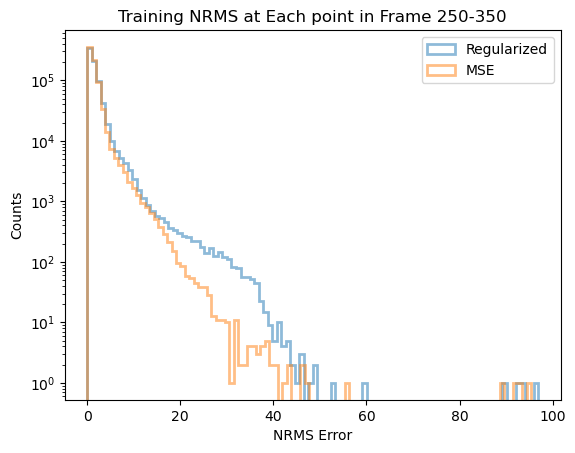

In [13]:
results = np.concatenate(stats)
mse_results = np.concatenate(mse_stats)

print(f' Regulrized NRMS: {results.mean()}, MSE NRMS: {mse_results.mean()}')

att = dict(histtype='step', linewidth = 2, alpha=0.5)
plt.hist(results, bins=100, **att, color='C0', label='Regularized')
plt.hist(mse_results, bins=100, **att, color='C1', label='MSE')
plt.yscale('log')
plt.xlabel('NRMS Error')
plt.ylabel('Counts')
plt.title('Training NRMS at Each point in Frame 250-350')
plt.legend()
plt.show()

In [10]:
stats = []
k=0
with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(torch.mean((pred_y - batch_y)**2)).item()*100
        stats.append(nrms)



In [5]:
avg_error = sum(stats)/len(stats)
print(f'Average RMS Error: {avg_error} cm')

Average RMS Error: 32.32579617202282 cm


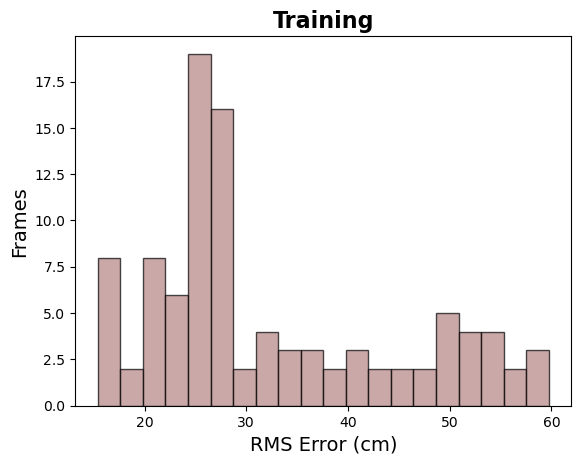

In [6]:
plt.hist(stats, bins=20, density=False, alpha=0.7, color="#B48383", edgecolor='black')
plt.xlabel('RMS Error (cm)', fontsize = 14)
plt.ylabel('Frames', fontsize = 14)
plt.title('Training', fontweight = 'bold', fontsize = 16)
plt.show()


## Testing

In [9]:
'Iterate through dataloader taking rms errors.'


data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams =[4,30]
# indices_to_remove = [10, 11]
# beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataset = pre_pro.FrameDataset(input, output)
spt_dataloader_test = DataLoader(dataset, shuffle=True, batch_size=1)


In [10]:
stats_test = []
k=0
with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader_test:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(torch.mean((pred_y - batch_y)**2)).item()*100
        stats_test.append(nrms)


In [13]:
avg_error_test = sum(stats_test)/len(stats_test)
print(f'Average RMS Error (Test Beams): {avg_error_test} cm')

Average RMS Error (Test Beams): 31.46412968635559 cm


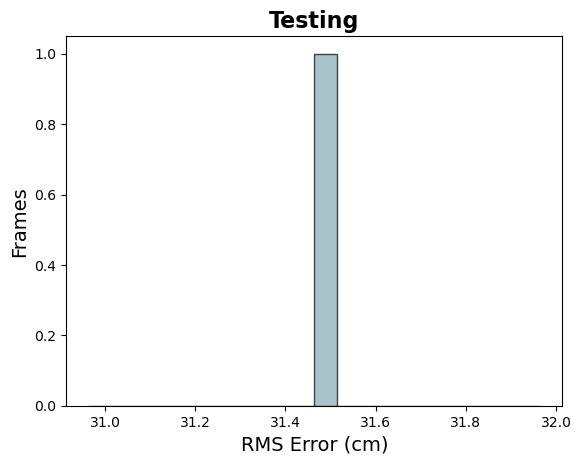

In [14]:
plt.hist(stats_test, bins=20, density=False, alpha=0.7, color="#83ACB4", edgecolor='black')
plt.xlabel('RMS Error (cm)', fontsize = 14)


plt.ylabel('Frames', fontsize = 14)

plt.title('Testing', fontweight = 'bold', fontsize = 16)
plt.show()

In [11]:
'one frame'


stats_test = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader_test:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        stats_test.append(nrms)


mse_stats_test = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader_test:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = mse_net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        mse_stats_test.append(nrms)


Regulirezed NRMS: 3.367457151412964, MSE NRMS: 1.8125993013381958


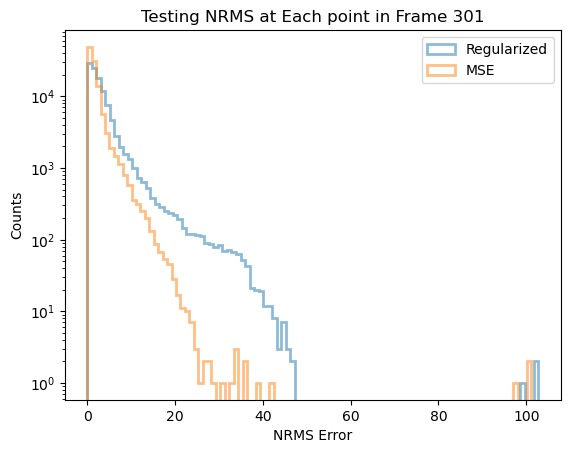

In [14]:
results = np.concatenate(stats_test)
mse_results = np.concatenate(mse_stats_test)

print(f'Regulirezed NRMS: {results.mean()}, MSE NRMS: {mse_results.mean()}')

att = dict(histtype='step', linewidth = 2, alpha=0.5)
plt.hist(results, bins=100, **att, color='C0', label='Regularized')
plt.hist(mse_results, bins=100, **att, color='C1', label='MSE')
plt.yscale('log')
plt.xlabel('NRMS Error')
plt.ylabel('Counts')
plt.title('Testing NRMS at Each point in Frame 301')
plt.legend()
plt.show()